# Homework 4

## Task 3

## Part 1: implementing word embeddings

**Model:**  
I will be using FastText because it's pre-trained, supports dynamic word lookup, and handles out-of-vocabulary words well with subword information.  
<br>
**Comparison:**  
- FastText vs. Word2vec: Word2Vec learns one vector per whole word and has no embedding for when it sees a word not present during training. FastText can approximate unseen words using subword units.
- FastText vs. GloVe: GloVe is static like Word2Vec so is less suitable for OOV words than FastText
- FastText vs BERT: BERT uses contextual references for embeddings of words which could introduce unnecessary complexity. This is because it would require sentences rather than just isolated words, and extracting embeddings is more computationally expensive.

**Load embeddings with Gensim**: using the gensim.downloader interface because it provides direct access to pre-trained models including FastText

In [2]:
!pip install gensim
import gensim.downloader as api
print(api.info()['models'].keys())
model = api.load('fasttext-wiki-news-subwords-300')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.7 MB/s eta 0:00:00
dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])
[==================================================] 100.0% 958.5/958.4MB downloaded


**user input of two words and output their embeddings**

In [6]:
def get_embedding(word, model):
  normalized = word.lower().strip()
  # return the embedding for a word with FastText
  try:
    # get vector representation of word
    vector = model[normalized]
    return vector
  # if not in model vocab, return None
  except KeyError:
    return None

# get words from user
word1 = input("Enter the first word: ").strip().lower()
word2 = input("Enter the second word: ").strip().lower()

# get vector representations of the words or None if not in vocab
embedding1 = get_embedding(word1, model)
embedding2 = get_embedding(word2, model)

# return embeddings
embeddings = {word1: embedding1, word2: embedding2}
for word, embedding in embeddings.items():
  if embedding is not None:
    print(f"Embedding for '{word}' is: {embedding}")
    print(f"Shape: {embedding.shape}")
  else:
    print(f"The word '{word}' is not in the vocabulary")

Enter the first word: fuming
Enter the second word: angry
Embedding for 'fuming' is: [ 0.012695    0.088714    0.026791    0.07486     0.013814   -0.016112
  0.0011598  -0.065889    0.0033104   0.045053   -0.058851   -0.079293
  0.0079703   0.023092   -0.031115   -0.0032458  -0.091744    0.015029
 -0.0046816   0.0095295   0.078641    0.052497   -0.010368    0.0087774
 -0.018134   -0.055531    0.048899    0.021541    0.014248   -0.0048027
 -0.039135    0.021006    0.043681   -0.026408   -0.0033723  -0.0047919
 -0.059934    0.016875   -0.079799   -0.022047   -0.039173   -0.052018
 -0.053915    0.040739    0.062419    0.046854    0.091165    0.079739
 -0.023181    0.087366    0.026443   -0.048007    0.072318    0.016468
 -0.018927   -0.075878   -0.056973   -0.041379   -0.074369    0.07619
  0.067439    0.072769   -0.015343    0.074087   -0.038535    0.042708
 -0.0058043  -0.013884    0.021715    0.0079958   0.010193    0.016827
  0.095447    0.013134   -0.00041666 -0.084541   -0.026082   

**Handle OOV cases and suggest ways to approximate its embedding**
<br>
<br>
I handle OOV cases with a try/except block that attempts to retrieve the vector representation of the word and returns None if the word is not in the model's vocabulary.  
  
<br>
Some possible approximation methods for OOV words are:  

- subword modeling: FastText does this automatically by building a word embedding by combining the vectors of its subwords
- normalizing: ensuring words are lowercase
- stemming: identifying words by their root, like running --> run
- spelling corrections: ensuring words are spelt properly
- averaging related known words

## Part 2: Cosine Similarity Computation

**Function that computes cosine similarity between two-word embeddings**

In [7]:
import numpy as np

# cosine similarity = A.B / (||A|| x ||B||)
def cos_sim(vec1, vec2): # takes embedding vector for word1 and for word2
  # check for OOV words
  if vec1 is None or vec2 is None:
    return None
  # compute dot product
  dot_prod = np.dot(vec1, vec2)
  # compute vector magnitudes
  vec1_norm = np.linalg.norm(vec1)
  vec2_norm = np.linalg.norm(vec2)
  # prevent division by 0
  if vec1_norm == 0 or vec2_norm == 0:
    return None
  # compute cosine similarity
  similarity = dot_prod / (vec1_norm * vec2_norm)
  return similarity

sim = cos_sim(embedding1, embedding2)
if sim is not None:
  print(f"\nCosine similarity between '{word1}' and '{word2}' is: {sim}")
else:
  print("\nCould not compute cosine similarity")


Cosine similarity between 'fuming' and 'angry' is: 0.5830950736999512


**Why cosine similarity is useful in word embeding space**  
<br>
Cosine similarity is commonly used in word embedding spaces because it measures the angle between vectors instead of comparing raw numbers. Word embeddings represent semantic relationships by placing words that appear in similar contexts near each other in vector space. Cosine similarity compares the angle between two vectors rather than their magnitude, allowing it to capture semantic similarity even when the vectors have different lengths. Smaller angles mean vectors point in similar directions and the meanings of the words are similar, while larger angles mean the vectors point in different ways and the words are unrelated.
<br>  
Cosine similarity ranges from 1, to 0, to -1. 1 means vectors point in the same direction and have almost identical meanings. 0 means the words are unrelated/orthogonal. -1 means the vectors point in exactly opposite directions and that the words appear in completely opposite contexts.
<br>
<br>
'fuming' and 'angry' having a cosine similarity of ~0.583 means they appear in similar contexts, but are not identical in meaning.

**Batch processing**

In [14]:
# function to allow user to dynamically build a list of word pairs for similariy computation
def get_inputs():
  pairs = []
  n = int(input("Enter number of pairs to compare: "))

  for i in range(n):
    word1 = input(f"Enter first word for pair {i+1}: ")
    word2 = input(f"Enter second word for pair {i+1}: ")
    pairs.append((word1, word2))
  return pairs

# function to get the cosine similarities of each pair of words in the user's list
def batch_cos_sim(word_pairs, model):
  results = []

  # iterate through each pair, get each word's vector embedding, get each pair of words' similarity, and store
  for word1, word2 in word_pairs:
    vec1 = get_embedding(word1, model)
    vec2 = get_embedding(word2, model)
    sim = cos_sim(vec1, vec2)
    results.append({
        "word1": word1,
        "word2": word2,
        "similarity": sim
    })
  return results

pairs = get_inputs()
results = batch_cos_sim(pairs, model)
for result in results:
  print(result)

Enter number of pairs to compare: 3
Enter first word for pair 1: cat
Enter second word for pair 1: dog
Enter first word for pair 2: dog
Enter second word for pair 2: wolf
Enter first word for pair 3: bear
Enter second word for pair 3: tree
{'word1': 'cat', 'word2': 'dog', 'similarity': np.float32(0.7502298)}
{'word1': 'dog', 'word2': 'wolf', 'similarity': np.float32(0.5919561)}
{'word1': 'bear', 'word2': 'tree', 'similarity': np.float32(0.40366971)}


**visualize how similar and dissimilar words cluster with 2D PCA scatter plot**

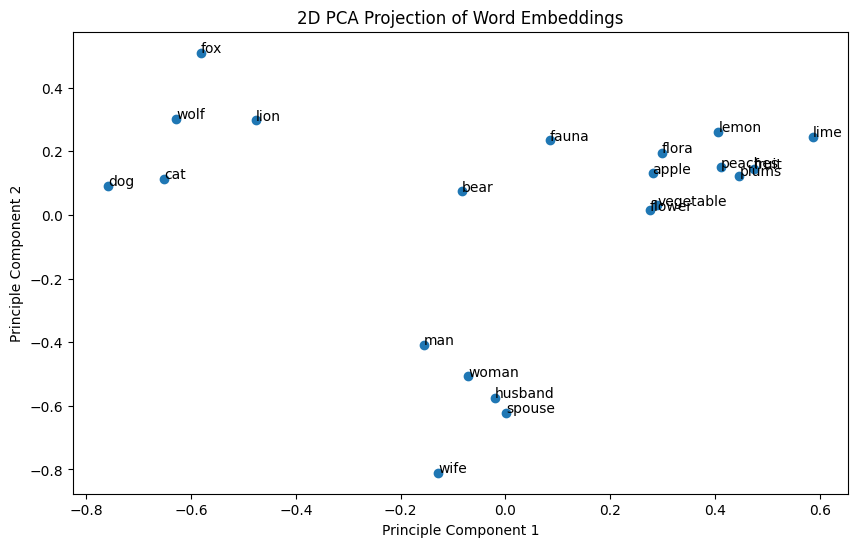

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# create list of words to cluster
words = [
    "cat", "dog", "lion", "wolf", "bear", "fox",
    "man", "woman", "husband", "wife", "spouse",
    "peaches", "plums", "lemon", "lime", "apple",
    "flora", "fauna", "flower", "fruit", "vegetable"
]

# collect embeddings for each word
embeddings = []
for word in words:
  embedding = get_embedding(word, model)
  if embedding is not None:
    embeddings.append(embedding)

embeddings = np.array(embeddings)

# reduce embeddings with PCA: 300D --> 2D for plotting
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# plot the reduced embeddings
plt.figure(figsize=(10, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
for i, word in enumerate(words):
  plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))

plt.title("2D PCA Projection of Word Embeddings")
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.show()


**Analysis**  
Animal-related words such as dog, cat, wolf, fox, and lion appear close together in the upper-left region, indicating the embedding model recognizes them as belonging to a similar semantic category. Bear is nearby but somewhat further towards the center of the plot, indicating it's still associated with animals but that it's contextual usage differs from the others.  
<br>
Second, a strong cluster around food and plant-related words forms in the upper-right region, with some words like vegetable and flower along with peaches, plums, and fruit being nearly on top of each other. This indicates the model sees these words as extremely similar in their contextual usage. 'Flora' is further towards the center than the overall cluster, which makes sense because it refers more to plant life in general than to specific categories.
<br>
<br>
Finally, a distinct cluster forms in the lower-middle region around terms concerning human relationships.

## Part 3: Designing a Novel Dissimilarity Metric

**Define a custom dissimilarity score that goes beyond cosine similarity. Cite and explain why it captures diversity better than cosine similarity alone.**
<br>
<br>
The dissimilarity score I'll be using is Euclidean distance.  
<br>
Cosine similarity examines the angle between two vectors to determine whether they're pointing in the same direction, and ignores the magnitude/length of the vectors. As a result, two vectors can have a high cosine similarity even if their lengths are dramatically different. Euclidean distance, on the other hand, measures the actual straight-line distance between two points to examine how far apart they are in the embedding space, taking vector length into account. This is important because two words can point in a similar semantic direction but still be meaningfully separated. Cosine similarity would not capture this separation, but Euclidean distance will.
<br>
<br>
A study by researchers in the Department of Psychology at UC Berkeley confirms the value of Euclidean distance for these purposes. It ran word2vec and GloVe to predict human relational similarity ratings between words and found that cosine similarity failed completely on a number of relations, including contrast and non-attribute relations. Using Euclidean distance boosted the performance on these relations, and often had a higher correlation with human judgements than cosine similarity across many relation types (Chen, Peterson, & Griffiths, 2017).
<br>
<br>
Chen, Dawn, Joshua C. Peterson, and Thomas L. Griffiths. “Evaluating Vector-Space Models of Analogy.” arXiv.org, June 8, 2017. https://arxiv.org/abs/1705.04416.

**Allow users to toggle between different measures via function parameters**

In [27]:
def cosine_similarity(vec1, vec2):
  if vec1 is None or vec2 is None:
    return None
  norm1 = np.linalg.norm(vec1)
  norm2 = np.linalg.norm(vec2)
  if norm1 == 0 or norm2 == 0:
    return None
  dot_prod = np.dot(vec1, vec2)
  similarity = dot_prod / (norm1 * norm2)
  return similarity

def euclidean_distance(vec1, vec2):
  if vec1 is None or vec2 is None:
    return None
  return np.linalg.norm(vec1 - vec2)

# function to allow users to toggle between measures for comparing words
def compare_words(word1, word2, model, measure="cosine"):
  measure = measure.lower().strip()
  vec1 = get_embedding(word1, model)
  vec2 = get_embedding(word2, model)

  if vec1 is None or vec2 is None:
    return None

  if measure == "cosine":
    return cosine_similarity(vec1, vec2)

  elif measure == "euclidean":
    return euclidean_distance(vec1, vec2)

  else:
    raise ValueError("measure must be either 'cosine' or 'euclidean'")

print("Cosine similarity for cat and dog:", compare_words("cat", "dog", model, "cosine"))
print("Euclidean distance for cat and dog:", compare_words("cat", "dog", model, "euclidean"))
print("\nCosine similarity for cat and lion:", compare_words("cat", "lion", model, "cosine"))
print("Euclidean distance for cat and lion:", compare_words("cat", "lion", model, "euclidean"))
print("\nCosine similarity cat and wolf:", compare_words("cat", "wolf", model, "cosine"))
print("Euclidean distance cat and wolf:", compare_words("cat", "wolf", model, "euclidean"))

Cosine similarity for cat and dog: 0.7502298
Euclidean distance for cat and dog: 1.0615107

Cosine similarity for cat and lion: 0.49322346
Euclidean distance for cat and lion: 1.42994

Cosine similarity cat and wolf: 0.49787572
Euclidean distance cat and wolf: 1.4217752


**Analysis**  
<br>
The cosine similarity between cat and dog is relatively high (0.75), while the similarities between cat and lion (0.49) and cat and wolf (0.50) are noticeably lower. This suggests that the embedding model considers cat to be more closely related to dog than to lion or wolf.
<br>
Euclidean distance is most meaningful when interrupted comparatively across word pairs. The distance between cat and dog (1.06) is smaller than the distances between cat and lion (1.43) and cat and wolf (1.42), indicating that dog lies closer to cat in the embedding space. The distances for lion and wolf are very similar, suggesting that the model views both animals a comparably related to cat.

**Plot ranking of words based on their similarity/dissimilarity to a given word**

Cosine Similarity Ranking:
   word     score
0   dog  0.750230
2  wolf  0.497876
1  lion  0.493223
3   fox  0.473808
5  milk  0.351060
4  tuna  0.340537

Euclidean Distance Ranking:
   word     score
0   dog  1.061511
2  wolf  1.421775
1  lion  1.429940
3   fox  1.498830
4  tuna  1.619042
5  milk  1.620214


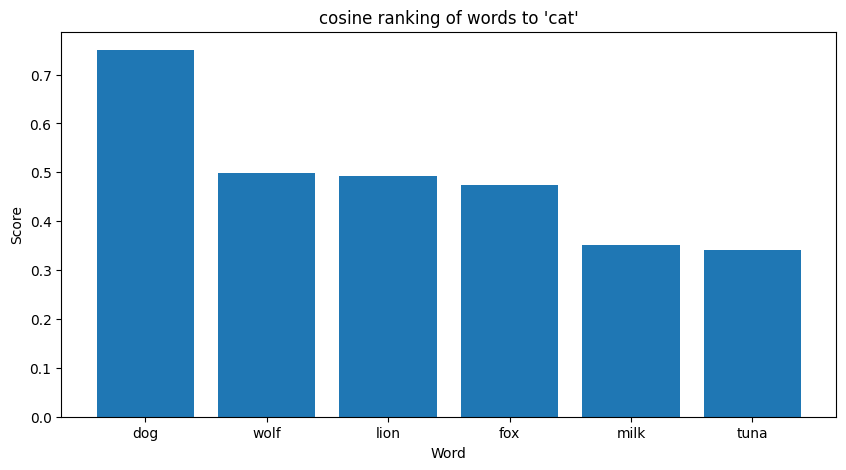

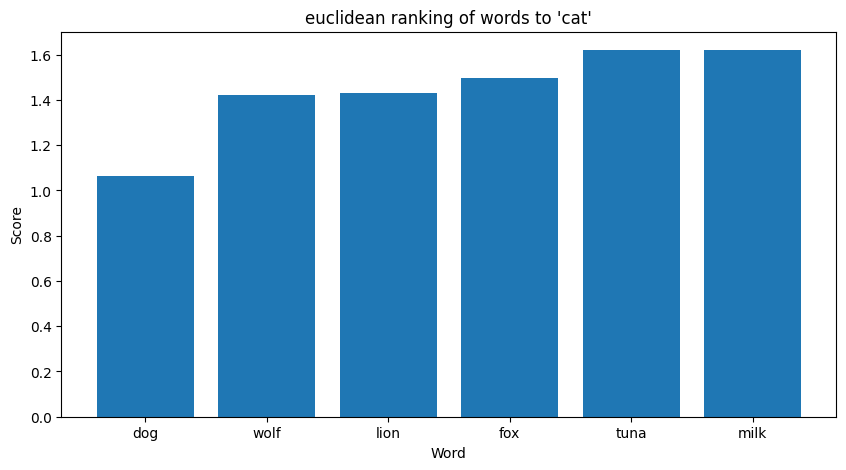

In [28]:
import pandas as pd

def rank_words(target, comparisons, model, measure="cosine"):
  results = []
  # compare each comparison word to the target word
  for word in comparisons:
    score = compare_words(target, word, model, measure=measure)
    results.append({"word": word, "score": score})
  results_df = pd.DataFrame(results)
  # for cosine, larger = more similar so sort descending
  if measure == "cosine":
    results_df = results_df.sort_values(by="score", ascending=False)
  # for euclidean, smaller = more similar so sort by ascending
  elif measure == "euclidean":
    results_df = results_df.sort_values(by="score", ascending=True)
  return results_df

# words to compare to the target word, 'cat'
comparisons = ["dog", "lion", "wolf", "fox", "tuna", "milk"]

cosine_ranking = rank_words("cat", comparisons, model, measure="cosine")
euclidean_ranking = rank_words("cat", comparisons, model, measure="euclidean")

print("Cosine Similarity Ranking:")
print(cosine_ranking)
print("\nEuclidean Distance Ranking:")
print(euclidean_ranking)

# function to make plotting more efficient
def plot_ranking(ranking_df, target, measure="cosine"):
  plt.figure(figsize=(10,5))
  plt.bar(ranking_df["word"], ranking_df["score"])
  plt.title(f"{measure} ranking of words to '{target}'")
  plt.xlabel("Word")
  plt.ylabel("Score")
  plt.show()

plot_ranking(cosine_ranking, "cat", measure="cosine")
plot_ranking(euclidean_ranking, "cat", measure="euclidean")


**Analysis**  
both the cosine and euclidean rankings place dog as the most closely related word to cat, however, cosine similarity puts milk slightly closer to cat than tuna while euclidean ranking orders tuna before milk. Cosine ranking also places a slightly greater dissimilarity between milk and tuna than euclidean does.

**Heatmap to compare similarity across multiple word pairs**

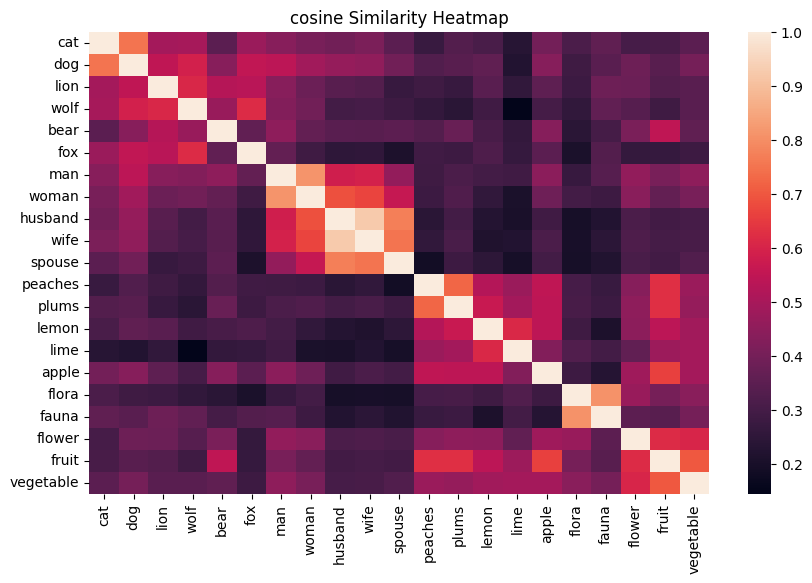

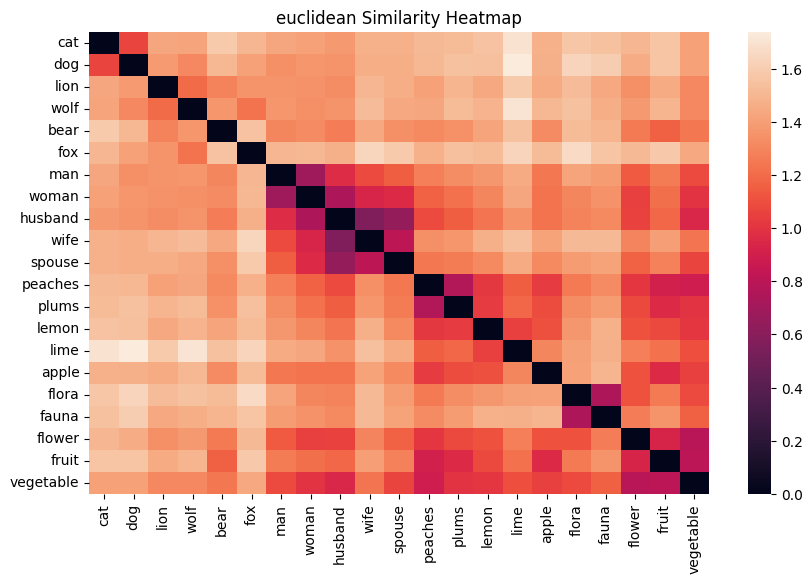

In [31]:
import seaborn as sns
words = [
    "cat", "dog", "lion", "wolf", "bear", "fox",
    "man", "woman", "husband", "wife", "spouse",
    "peaches", "plums", "lemon", "lime", "apple",
    "flora", "fauna", "flower", "fruit", "vegetable"
]

def build_matrix(words, model, measure="cosine"):
  matrix = []
  for word1 in words:
    row = []
    for word2 in words:
      score = compare_words(word1, word2, model, measure=measure)
      row.append(score)
    matrix.append(row)
  return np.array(matrix)


def plot_heatmap(words, matrix, measure="cosine"):
  plt.figure(figsize=(10, 6))
  sns.heatmap(matrix, xticklabels=words, yticklabels=words)
  plt.title(f"{measure} Similarity Heatmap")
  plt.show()

cosine_matrix = build_matrix(words, model, measure="cosine")
euclidean_matrix = build_matrix(words, model, measure="euclidean")

plot_heatmap(words, cosine_matrix, measure="cosine")
plot_heatmap(words, euclidean_matrix, measure="euclidean")



**Analysis**  
across both cosine and euclidean heatmaps, clear clusters form for the animal, human relation, and plants groups, with relatively high cosine similarity values and lower euclidean distances. They reveal correlations between unexpected and largely unrelated pairs as well, such as vegetable and husband.